In [ ]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [ ]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

* 모든 설치가 끝나면 한글 폰트를 바르게 출력하기 위해 **[런타임]** -> **[런타임 다시시작]**을 클릭한 다음, 아래 셀부터 코드를 실행해 주십시오.

In [ ]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [ ]:
# 파이토치 관련 라이브러리

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torchviz import make_dot
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as datasets

In [ ]:
# warning 표시 끄기
import warnings
warnings.simplefilter('ignore')

# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [ ]:
# GPU 디바이스 할당

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
# 분류 클래스 명칭 리스트
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 분류 클래스 수,　10
n_output = len(list(set(classes)))

# 결과 확인
print(n_output)

10


## 10.3 최적화 함수

### SGD

In [ ]:
# 가상의 파라미터와 그래디언트 생성
W = torch.randn(3, 3, requires_grad=True)
B = torch.randn(3, requires_grad=True)
W.grad = torch.randn(3, 3)
B.grad = torch.randn(3)

# 파라미터 갱신
# 학습률
lr = 0.001
# 경사를 기반으로 파라미터 갱신
W.data -= lr * W.grad.data
B.data -= lr * B.grad.data

print("Updated W:\n", W)
print("Updated B:\n", B)

Updated W:
 tensor([[ 1.0154,  0.0216,  1.8590],
        [ 0.4639,  0.5318,  1.7234],
        [-0.7192, -0.2846,  0.3803]], requires_grad=True)
Updated B:
 tensor([ 0.1548, -0.8256, -0.0950], requires_grad=True)


### 모멘텀

In [ ]:
# 가상의 모델 파라미터
net_params = [torch.randn(10, 1, requires_grad=True)]

# 모멘텀
optimizer = optim.SGD(net_params, lr=lr, momentum=0.9) # momentum 값을 0.9로 지정

print(optimizer)    # key, value 형식

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)


In [ ]:
net_params

[tensor([[ 1.9381],
         [-1.1095],
         [ 0.2184],
         [-0.2661],
         [ 0.2320],
         [-0.8001],
         [-0.4885],
         [ 0.0971],
         [ 0.3635],
         [-1.1959]], requires_grad=True)]

### Adam

In [ ]:
# 가상의 모델 파라미터
net_params = [torch.randn(10, 1, requires_grad=True)]

# Adam
optimizer = optim.Adam(net_params)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 10.4 과학습의 대응 방법

### 드랍 아웃 함수 동작 확인

In [ ]:
# 드랍 아웃 실험용 더미 데이터 작성
torch.manual_seed(123) # 결과를 재현하기 위해 난수 시드 고정
inputs = torch.randn(1, 10) # 1x10 크기의 텐서 생성
print("Original Inputs:")
print(inputs)

Original Inputs:
tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969,  0.2093, -0.9724, -0.7550,
          0.3239, -0.1085]])


In [ ]:
# 드랍 아웃 함수 정의
dropout = nn.Dropout(0.5) # 50%의 확률로 뉴런을 비활성화

# 훈련 페이즈에서의 거동
dropout.train() # 모델을 훈련 모드로 설정
print(f"Is in training mode? : {dropout.training}")
outputs = dropout(inputs)
print("Outputs in Train Mode:")
print(outputs)

# 예측 페이즈에서의 거동
dropout.eval() # 모델을 평가 모드로 설정
print(f"Is in training mode? : {dropout.training}")
outputs = dropout(inputs)
print("Outputs in Eval Mode:")
print(outputs)

Is in training mode? : True
Outputs in Train Mode:
tensor([[-0.0000,  0.2407, -0.7393, -0.4808, -2.3938,  0.4185, -0.0000, -1.5101,
          0.0000, -0.2170]])
Is in training mode? : False
Outputs in Eval Mode:
tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969,  0.2093, -0.9724, -0.7550,
          0.3239, -0.1085]])


### 데이터 증강

In [ ]:
# Transforms를 사용한 데이터 증강 구현
# 훈련 데이터용: 정규화에 추가로 반전과 RandomErasing 수행
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # 50% 확률로 좌우 반전
    transforms.ToTensor(), # 이미지를 텐서로 변환(default dtype=float32)
    # 이미지 [0-255] px 단위 범위 : [255,0,0] >> 텐서 [0-1] 실수 [1,0,0]
    transforms.Normalize((0.5,), (0.5,)), # 정규화(평균, 표준편차) mean: 0.5, std: 0.5
    #  x - mean / sigma(std) = (x-0.5) / 0.5 >> 값의 범위 [-1, 1]
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False)
    # 50% 확률로 이미지의 일부 영역을 지움
    # scale = 0.02(2%)~0.33(33%) 영역을 지운다.영역을 가린다
    # ratio=(0.3, 3.3): 가려진 영역 가로/세로 비율
    # value=0 : 검정색(0) 채움
    # inplace=False : 원본 유지
])

print(transform_train)

Compose(
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=(0.5,), std=(0.5,))
    RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False)
)


In [ ]:
# # 실습
# transform_train = transforms.Compose([
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5)),
#     transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False)
# ])

## 10.5 공통 함수의 라이브러리화

In [1]:
# 공통 함수 다운로드
!git clone https://github.com/wikibook/pythonlibs.git

# 공통 함수 불러오기
from pythonlibs.torch_lib1 import *

# 공통 함수 확인
print(README)

Cloning into 'pythonlibs'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 25 (delta 6), reused 25 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 21.10 MiB | 21.89 MiB/s, done.
Resolving deltas: 100% (6/6), done.


ModuleNotFoundError: No module named 'torchviz'

## 데이터 준비

In [ ]:
# Transforms의 정의

transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize(0.5, 0.5) #(평균 mean, 표준편차 std)
])
# 텐서 변환 >> 정규화 해줘

In [ ]:
# 데이터 취득용 함수 dataset

data_root = './data'

train_set = datasets.CIFAR10(
    root = data_root, train = True,
    download = True, transform = transform)

# 검증 데이터셋
test_set = datasets.CIFAR10(
    root = data_root, train = False,
    download = True, transform = transform)

100%|██████████| 170M/170M [00:14<00:00, 11.8MB/s]


In [ ]:
# 미니 배치 사이즈 지정
batch_size = 100

# 훈련용 데이터로더
# 훈련용이므로 셔플을 True로 설정
train_loader = DataLoader(train_set,
    batch_size = batch_size, shuffle = True)

# 검증용 데이터로더
# 검증용이므로 셔플하지 않음
test_loader = DataLoader(test_set,
    batch_size = batch_size, shuffle = False)

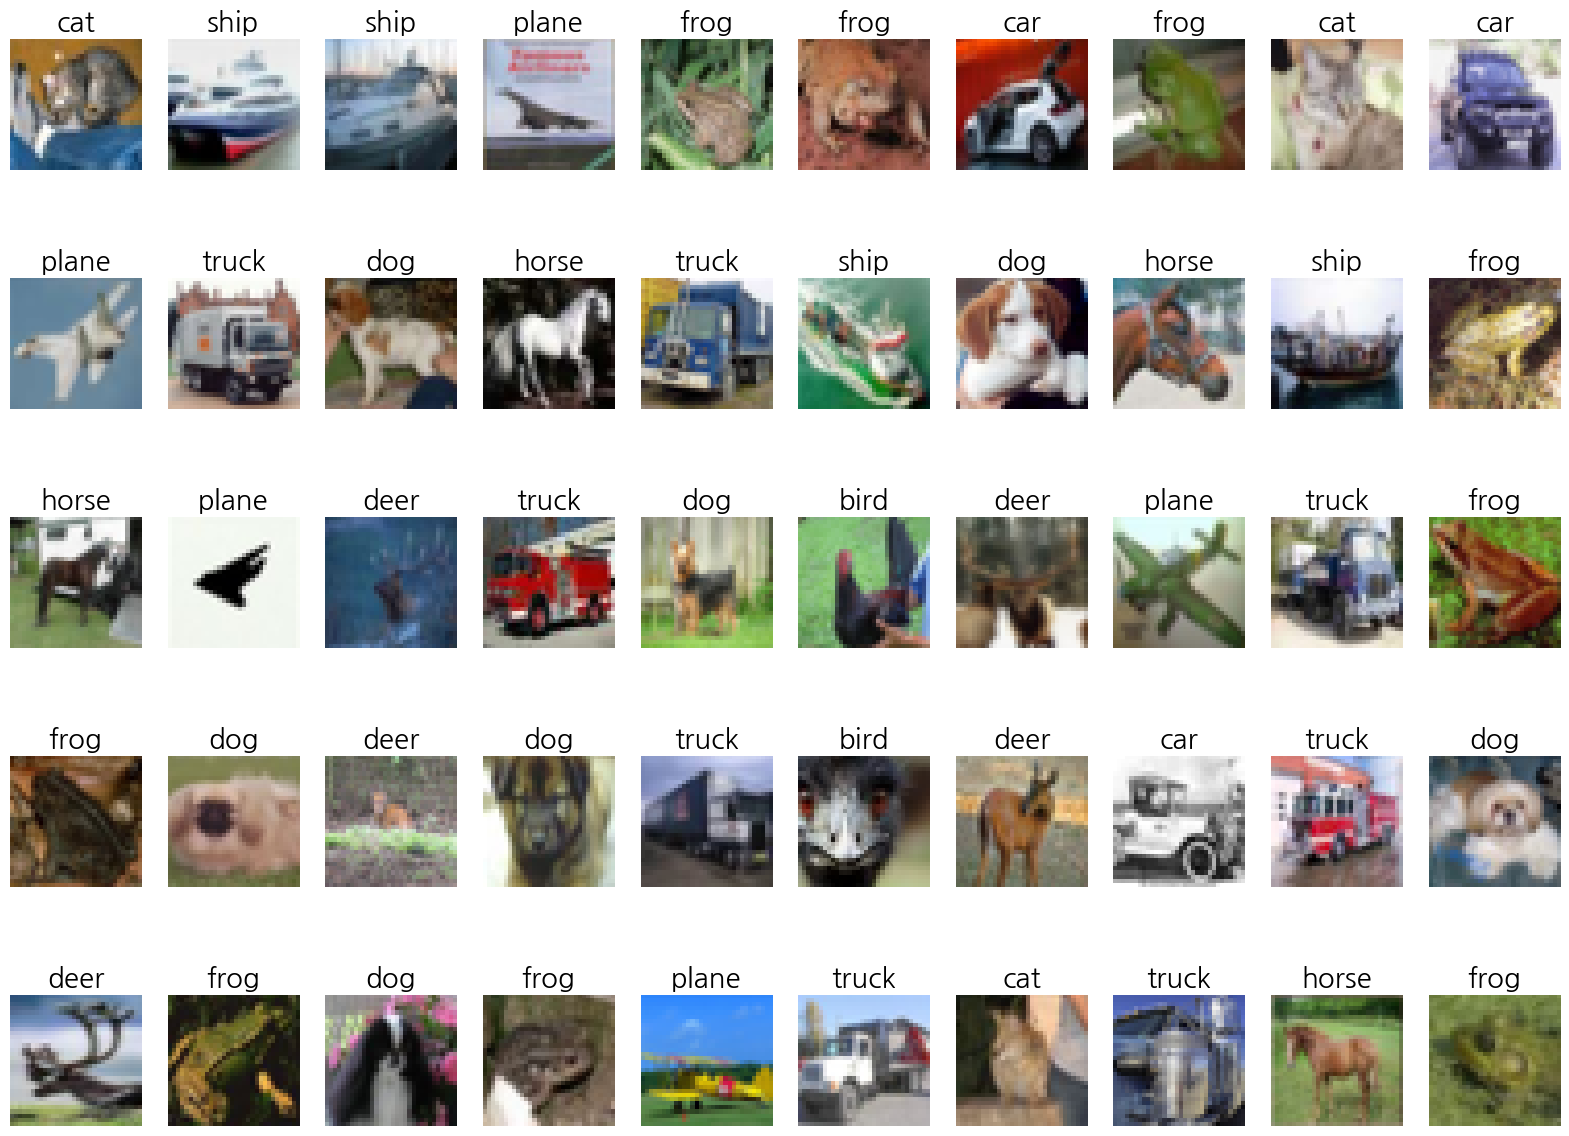

In [ ]:
# 처음 50개 이미지 출력
show_images_labels(test_loader, classes, None, None)
# None, None : 모델, 디바이스

## 10.6 층을 깊게 쌓은 모델 구현하기

In [ ]:
class CNN_v2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # 합성곱, ReLU, MaxPool 레이어 정의
        self.conv1 = nn.Conv2d(3, 32, 3, padding=(1,1))
        # padding=(1,1) 이미지 크기 유지 ; padding='same'
        self.conv2 = nn.Conv2d(32, 32, 3, padding=(1,1))
        self.conv3 = nn.Conv2d(32, 64, 3, padding=(1,1))
        self.conv4 = nn.Conv2d(64, 64, 3, padding=(1,1))
        self.conv5 = nn.Conv2d(64, 128, 3, padding=(1,1))
        self.conv6 = nn.Conv2d(128, 128, 3, padding=(1,1))
        self.relu = nn.ReLU(inplace=True)
        self.flatten = nn.Flatten()
        self.maxpool = nn.MaxPool2d((2,2))

        # 선형(Fully Connected) 레이어 정의
        self.l1 = nn.Linear(4*4*128, 128)
        self.l2 = nn.Linear(128, num_classes)

        # 레이어들을 순차적으로 실행할 `nn.Sequential` 정의
        self.features = nn.Sequential(
            self.conv1,
            self.relu,
            self.conv2,
            self.relu,
            self.maxpool,
            self.conv3,
            self.relu,
            self.conv4,
            self.relu,
            self.maxpool,
            self.conv5,
            self.relu,
            self.conv6,
            self.relu,
            self.maxpool,
            )

        self.classifier = nn.Sequential(
            self.l1,
            self.relu,
            self.l2
        )

    def forward(self, x):
        x1 = self.features(x)
        x2 = self.flatten(x1)
        x3 = self.classifier(x2)
        return x3

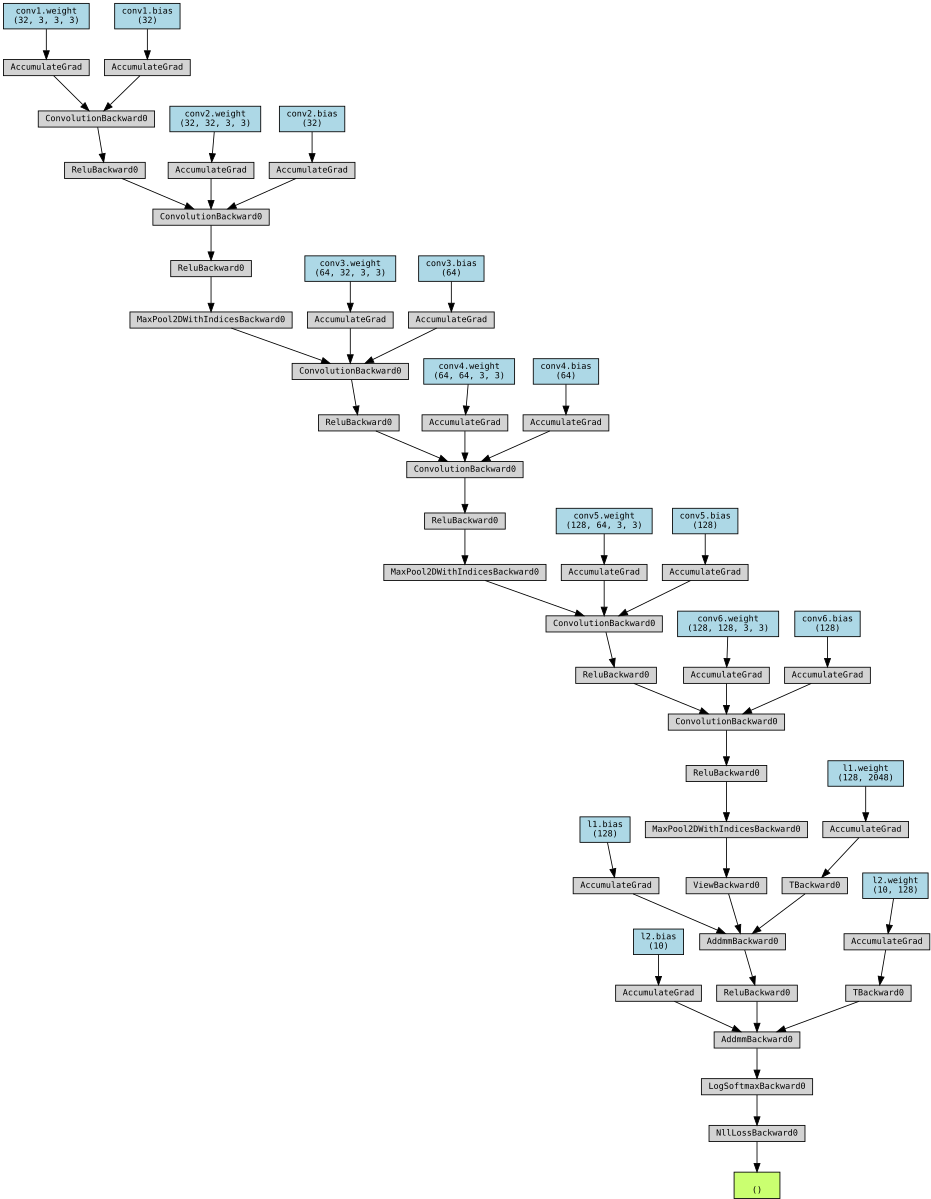

In [ ]:
# 손실 계산 그래프 시각화
net = CNN_v2(n_output).to(device)
criterion = nn.CrossEntropyLoss()
loss = eval_loss(test_loader, device, net, criterion)
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

In [ ]:
# 난수 고정
torch_seed()

# 모델 인스턴스 생성
lr = 0.01
net = CNN_v2(n_output).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=lr)
history = np.zeros((0, 5))

In [ ]:
# 학습

num_epochs = 50
history = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/50], loss: 0.02303 acc: 0.10000 val_loss: 0.02303, val_acc: 0.10000


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/50], loss: 0.02303 acc: 0.10000 val_loss: 0.02303, val_acc: 0.10000


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [48/50], loss: 0.00374 acc: 0.86888 val_loss: 0.01061, val_acc: 0.69830


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [49/50], loss: 0.00347 acc: 0.87842 val_loss: 0.01060, val_acc: 0.70530


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [50/50], loss: 0.00310 acc: 0.89092 val_loss: 0.01114, val_acc: 0.71050


초기상태 : 손실 : 0.02303  정확도 : 0.10000
최종상태 : 손실 : 0.01114 정확도 : 0.71050


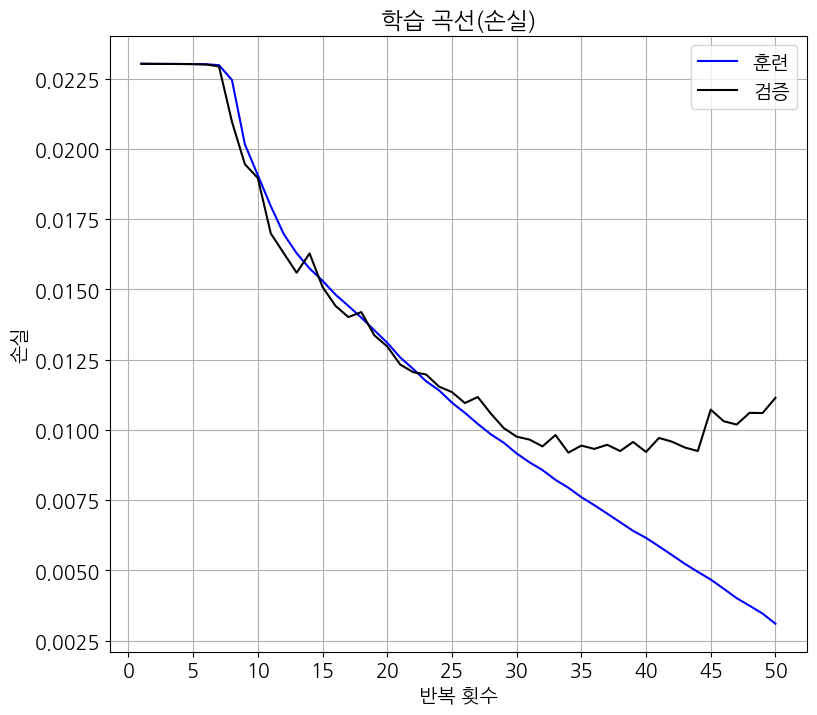

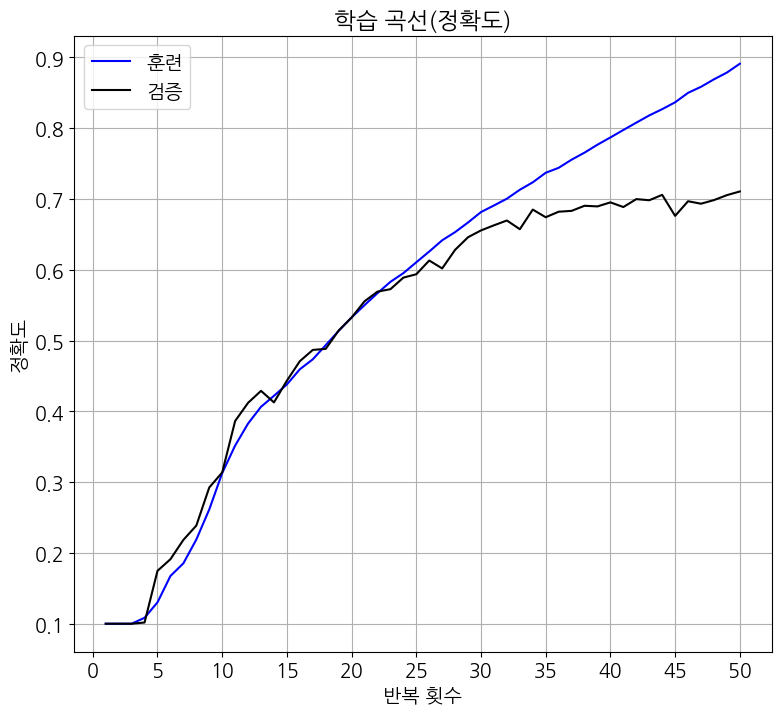

In [ ]:
evaluate_history(history)

## 10.7 최적화 함수 선택

### 모멘텀 설정

In [ ]:
# 난수 고정
torch_seed()

# 모델 인스턴스 생성
lr = 0.01
net = CNN_v2(n_output).to(device)
criterion = nn.CrossEntropyLoss()

# 최적화 함수에 모멘텀 값 설정
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
# momentum=0.9 : 이전 업데이트되는 방향을 90% 반영 >> 학습속도 높이고 안정화
history2 = np.zeros((0, 5))

In [ ]:
# 학습

num_epochs = 20
history2 = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history2)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/20], loss: 0.02284 acc: 0.12270 val_loss: 0.02044, val_acc: 0.24590


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/20], loss: 0.01801 acc: 0.33784 val_loss: 0.01518, val_acc: 0.42890


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [18/20], loss: 0.00109 acc: 0.96232 val_loss: 0.01184, val_acc: 0.76550


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [19/20], loss: 0.00094 acc: 0.96764 val_loss: 0.01253, val_acc: 0.76320


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [20/20], loss: 0.00077 acc: 0.97322 val_loss: 0.01249, val_acc: 0.76120


초기상태 : 손실 : 0.02044  정확도 : 0.24590
최종상태 : 손실 : 0.01249 정확도 : 0.76120


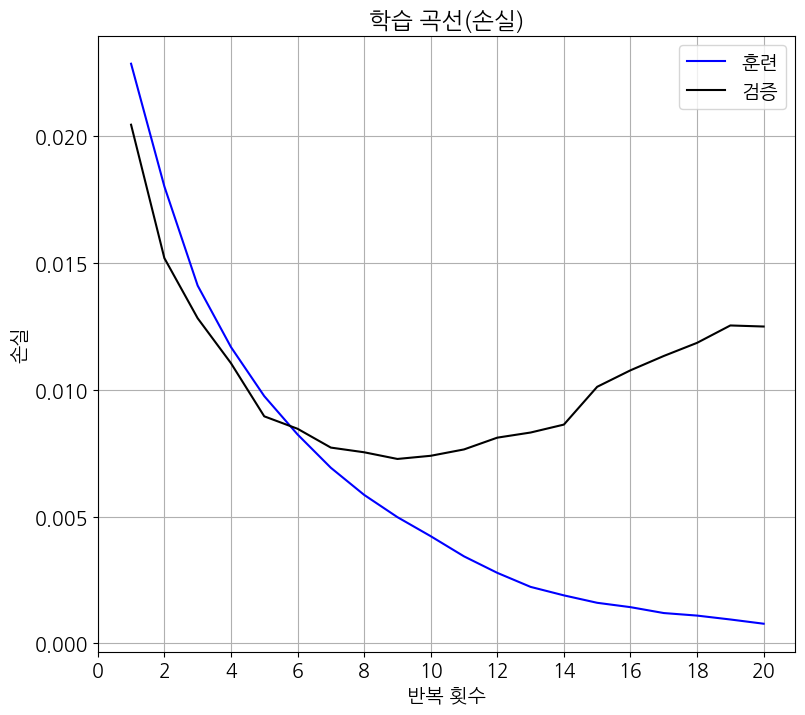

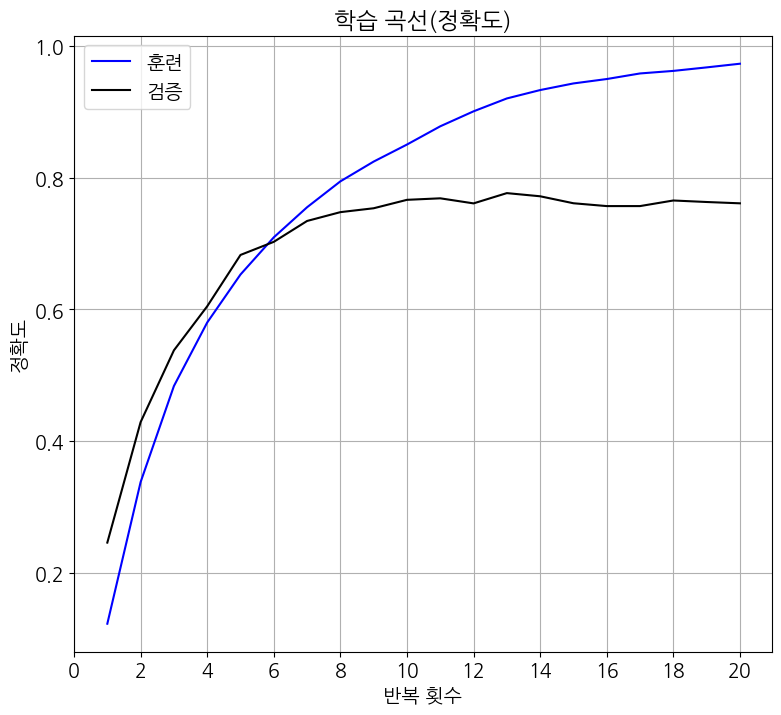

In [ ]:
evaluate_history(history2)

### Adam 함수 사용

In [ ]:
# 난수 고정
torch_seed()

# 모델 인스턴스 생성
net = CNN_v2(n_output).to(device)
criterion = nn.CrossEntropyLoss()

# 최적화 함수를 Adam으로 교체
optimizer = optim.Adam(net.parameters())
history3 = np.zeros((0, 5))

In [ ]:
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
# 학습

num_epochs = 20
history3 = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history3)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/20], loss: 0.01596 acc: 0.41856 val_loss: 0.01256, val_acc: 0.54980


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/20], loss: 0.01102 acc: 0.60418 val_loss: 0.01032, val_acc: 0.63490


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [18/20], loss: 0.00090 acc: 0.96886 val_loss: 0.01409, val_acc: 0.75800


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [19/20], loss: 0.00087 acc: 0.97016 val_loss: 0.01299, val_acc: 0.76070


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [20/20], loss: 0.00073 acc: 0.97462 val_loss: 0.01471, val_acc: 0.75670


초기상태 : 손실 : 0.01256  정확도 : 0.54980
최종상태 : 손실 : 0.01471 정확도 : 0.75670


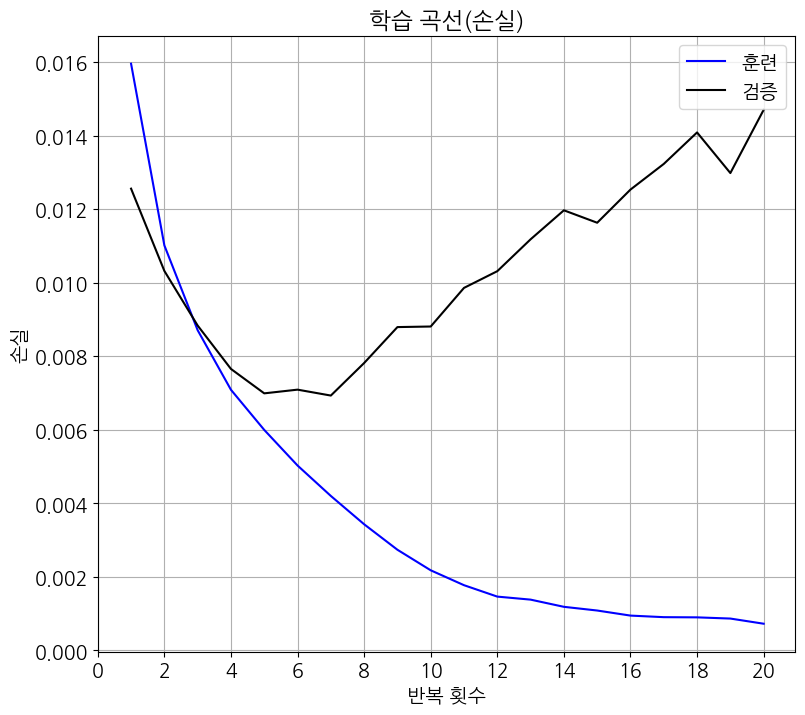

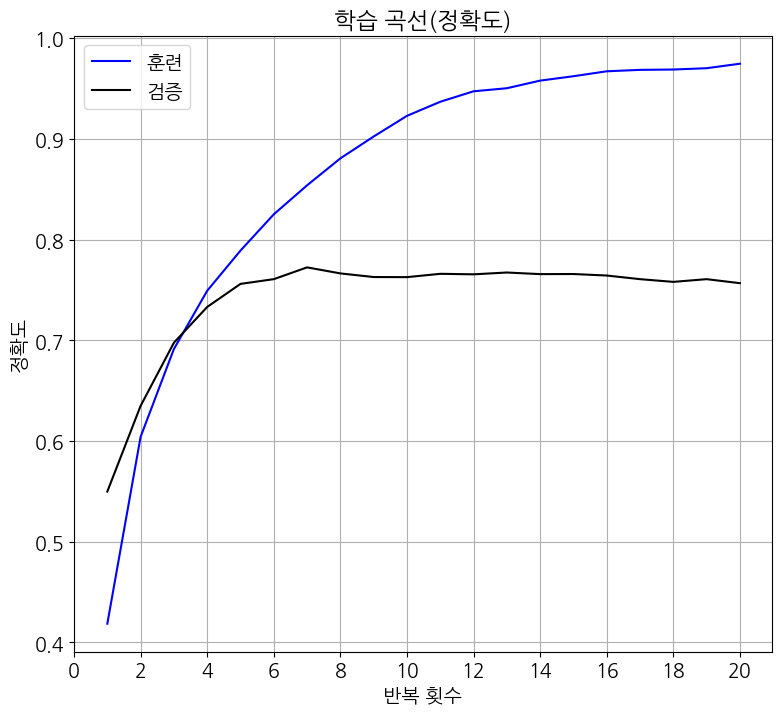

In [ ]:
evaluate_history(history3)

### 결과 비교

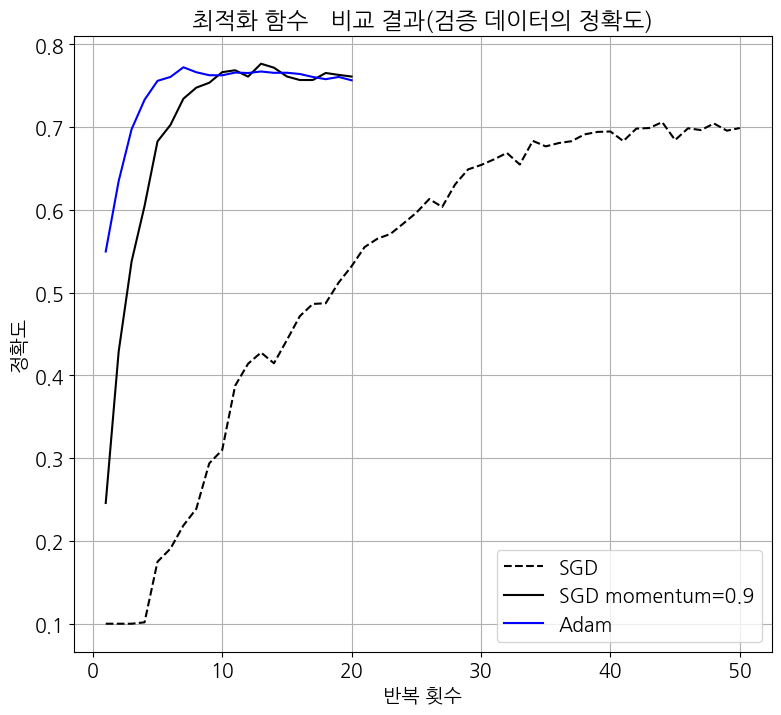

In [ ]:
# 결과 비교(검증 데이터의 정확도)
plt.figure(figsize=(9,8))
plt.plot(history[:,0], history[:,4], label='SGD', c='k',ls='dashed' )
plt.plot(history2[:,0], history2[:,4], label='SGD momentum=0.9', c='k')
plt.plot(history3[:,0], history3[:,4], label='Adam', c='b')
plt.title('최적화 함수　비교 결과(검증 데이터의 정확도)')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.legend()
plt.show()

## 10.8 드랍 아웃

In [ ]:
class CNN_v3(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # ... (이전 conv, relu, maxpool 등 정의는 동일) ...
        self.conv1 = nn.Conv2d(3, 32, 3, padding=(1,1))
        self.conv2 = nn.Conv2d(32, 32, 3, padding=(1,1))
        self.conv3 = nn.Conv2d(32, 64, 3, padding=(1,1))
        self.conv4 = nn.Conv2d(64, 64, 3, padding=(1,1))
        self.conv5 = nn.Conv2d(64, 128, 3, padding=(1,1))
        self.conv6 = nn.Conv2d(128, 128, 3, padding=(1,1))
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d((2,2))
        self.flatten = nn.Flatten()

        self.l1 = nn.Linear(4*4*128, 128)
        self.l2 = nn.Linear(128, 10)

        # 드롭아웃 레이어를 비율을 다르게 하여 3개 정의
        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.3)
        self.dropout3 = nn.Dropout(0.4)

        self.features = nn.Sequential(
            self.conv1, self.relu,
            self.conv2, self.relu, self.maxpool,
            self.dropout1, # 첫 번째 MaxPool 뒤에 추가
            self.conv3, self.relu,
            self.conv4, self.relu, self.maxpool,
            self.dropout2, # 두 번째 MaxPool 뒤에 추가
            self.conv5, self.relu,
            self.conv6, self.relu, self.maxpool,
            self.dropout3, # 세 번째 MaxPool 뒤에 추가

        )
        self.classifier = nn.Sequential(
            self.l1, self.relu,
            self.dropout3, # 분류기의 선형 레이어 사이에 추가
            self.l2
        )

    def forward(self, x):
        x1 = self.features(x)
        x2 = self.flatten(x1)
        x3 = self.classifier(x2)
        return x3

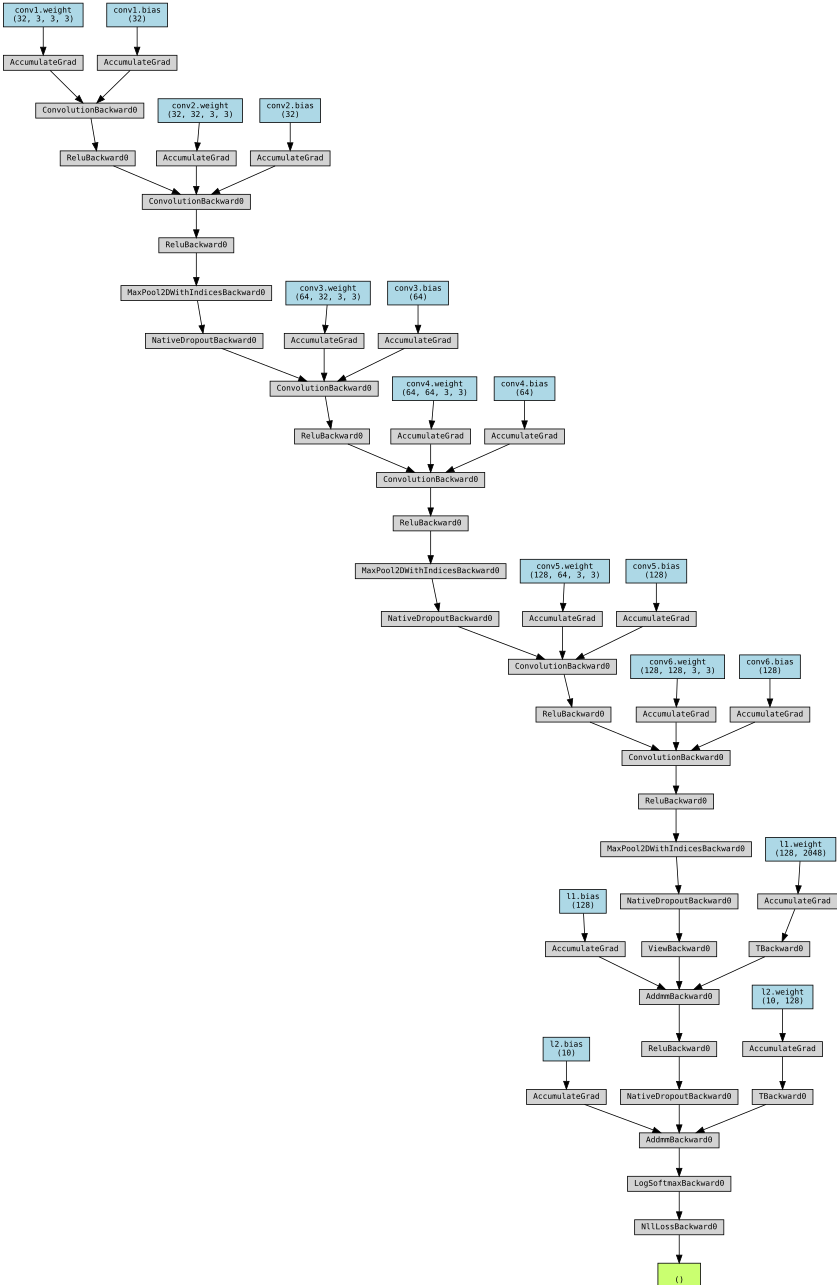

In [ ]:
# 손실 계산 그래프 시각화
net = CNN_v3(n_output).to(device)
criterion = nn.CrossEntropyLoss()
loss = eval_loss(test_loader, device, net, criterion)
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

In [ ]:
# 난수 고정
torch_seed()

# 모델 인스턴스 생성
net = CNN_v3(n_output).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())
history = np.zeros((0, 5))

In [ ]:
# 학습

num_epochs = 50
history = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/50], loss: 0.01730 acc: 0.35308 val_loss: 0.01322, val_acc: 0.52250


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/50], loss: 0.01298 acc: 0.52706 val_loss: 0.01069, val_acc: 0.61220


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [48/50], loss: 0.00393 acc: 0.86264 val_loss: 0.00549, val_acc: 0.83000


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [49/50], loss: 0.00385 acc: 0.86584 val_loss: 0.00516, val_acc: 0.83500


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [50/50], loss: 0.00385 acc: 0.86584 val_loss: 0.00534, val_acc: 0.83520


초기상태 : 손실 : 0.01322  정확도 : 0.52250
최종상태 : 손실 : 0.00534 정확도 : 0.83520


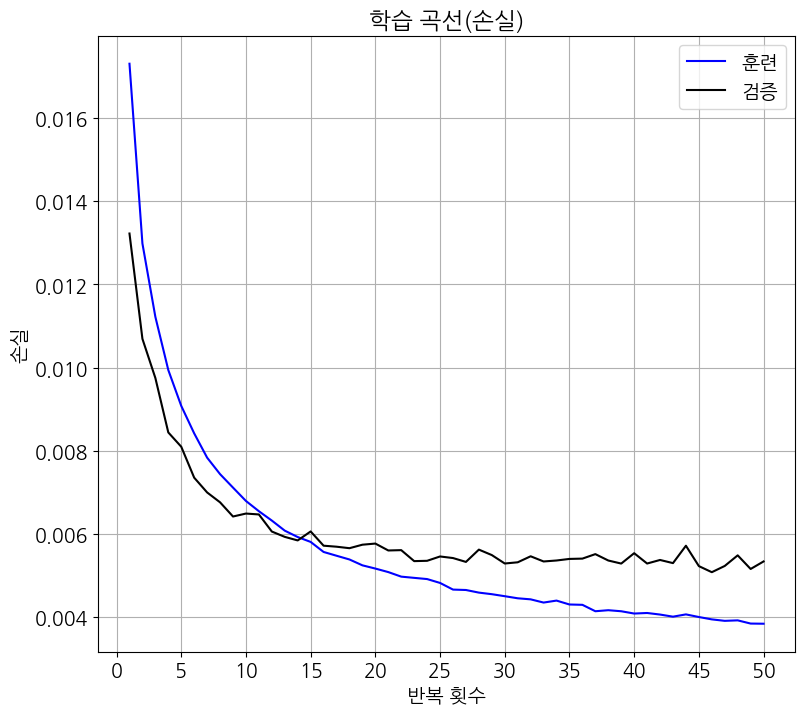

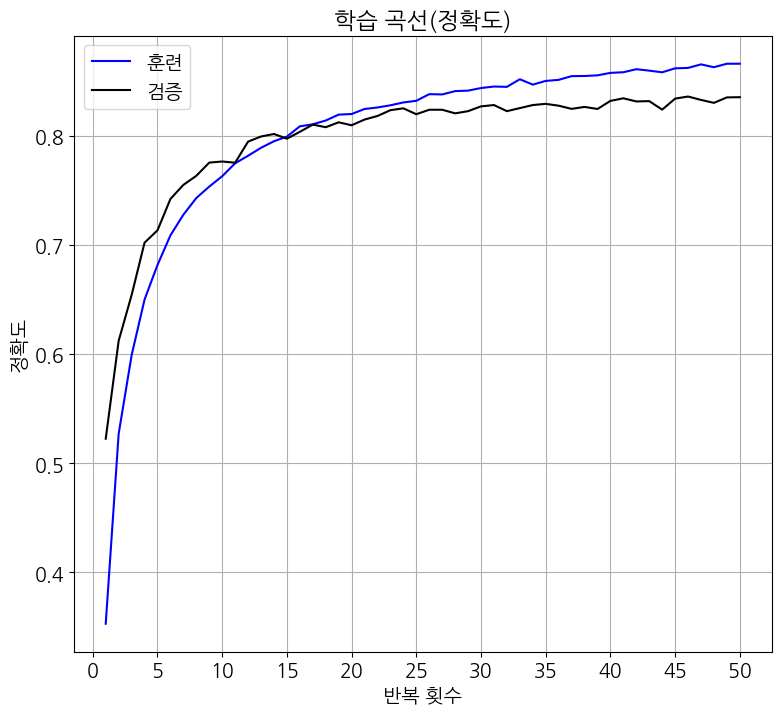

In [ ]:
evaluate_history(history)

## 10.9 배치 정규화

In [ ]:
class CNN_v4(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # ... (이전 conv, relu, maxpool, dropout 등 정의는 동일) ...
        self.conv1 = nn.Conv2d(3, 32, 3, padding=(1,1))
        self.conv2 = nn.Conv2d(32, 32, 3, padding=(1,1))
        self.conv3 = nn.Conv2d(32, 64, 3, padding=(1,1))
        self.conv4 = nn.Conv2d(64, 64, 3, padding=(1,1))
        self.conv5 = nn.Conv2d(64, 128, 3, padding=(1,1))
        self.conv6 = nn.Conv2d(128, 128, 3, padding=(1,1))
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d((2,2))
        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.3)
        self.dropout3 = nn.Dropout(0.4)
        self.flatten = nn.Flatten()

        self.l1 = nn.Linear(128 * 4* 4, 512)
        self.l2 = nn.Linear(512, num_classes)


        # 각 Conv 레이어의 출력 채널 수에 맞춰 BatchNorm2d 레이어 정의
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(32)
        self.bn3 = nn.BatchNorm2d(64)
        self.bn4 = nn.BatchNorm2d(64)
        self.bn5 = nn.BatchNorm2d(128)
        self.bn6 = nn.BatchNorm2d(128)

        self.features = nn.Sequential(
            self.conv1, self.bn1, self.relu, # conv1 -> bn1 -> relu
            self.conv2, self.bn2, self.relu, self.maxpool, # conv2 -> bn2 -> relu
            self.dropout1,
            self.conv3, self.bn3, self.relu, # conv3 -> bn3 -> relu
            self.conv4, self.bn4, self.relu, self.maxpool, # conv4 -> bn4 -> relu
            self.dropout2,
            self.conv5, self.bn5, self.relu, # conv5 -> bn5 -> relu
            self.conv6, self.bn6, self.relu, self.maxpool, # conv6 -> bn6 -> relu
            self.dropout3,
        )

        self.classifier = nn.Sequential(
            self.l1,
            self.relu,
            self.dropout3,
            self.l2
        )

    def forward(self, x):
        x1 = self.features(x)
        x2 = self.flatten(x1)
        x3 = self.classifier(x2)
        return x3

In [ ]:
# 난수 고정
torch_seed()

# 모델 인스턴스 생성
net = CNN_v4(n_output).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())
history = np.zeros((0, 5))

In [ ]:
# 학습

num_epochs = 50
history = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/50], loss: 0.01425 acc: 0.47784 val_loss: 0.01104, val_acc: 0.60390


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/50], loss: 0.01006 acc: 0.64042 val_loss: 0.00831, val_acc: 0.70520


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [48/50], loss: 0.00203 acc: 0.92864 val_loss: 0.00432, val_acc: 0.87190


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [49/50], loss: 0.00202 acc: 0.92922 val_loss: 0.00460, val_acc: 0.86770


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [50/50], loss: 0.00204 acc: 0.92820 val_loss: 0.00429, val_acc: 0.87540


초기상태 : 손실 : 0.01104  정확도 : 0.60390
최종상태 : 손실 : 0.00429 정확도 : 0.87540


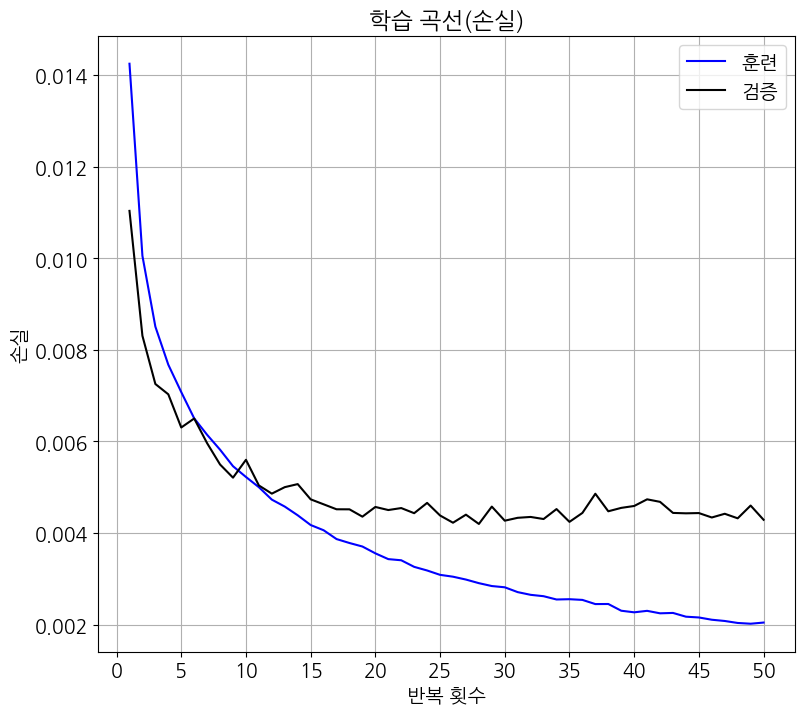

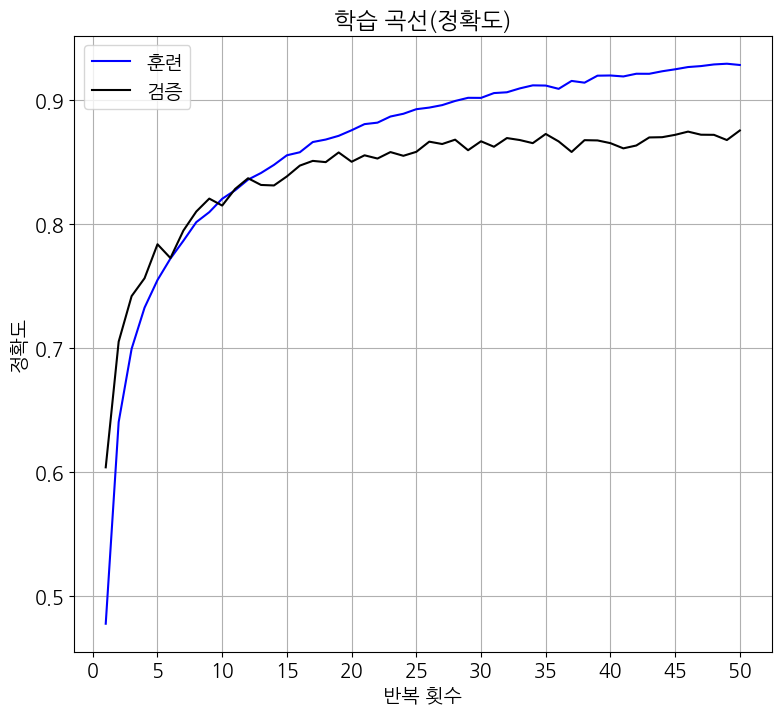

In [ ]:
evaluate_history(history)

## 10.10 데이터 증강 기법

In [ ]:
# 훈련 데이터용: 정규화에 반전과 RandomErasing 추가
transform_train = transforms.Compose([
  transforms.RandomHorizontalFlip(p=0.5), # 50% 확률로 좌우 반전
  transforms.ToTensor(),
  transforms.Normalize(0.5, 0.5),
  transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False)
])

In [ ]:
# transfrom_train을 사용한 데이터셋 정의
train_set2 = datasets.CIFAR10(
    root = data_root, train = True,
    download = True, transform = transform_train)

# traisform_train을 사용한 데이터로더 정의
batch_size = 100
train_loader2 = DataLoader(train_set2, batch_size=batch_size, shuffle=True)

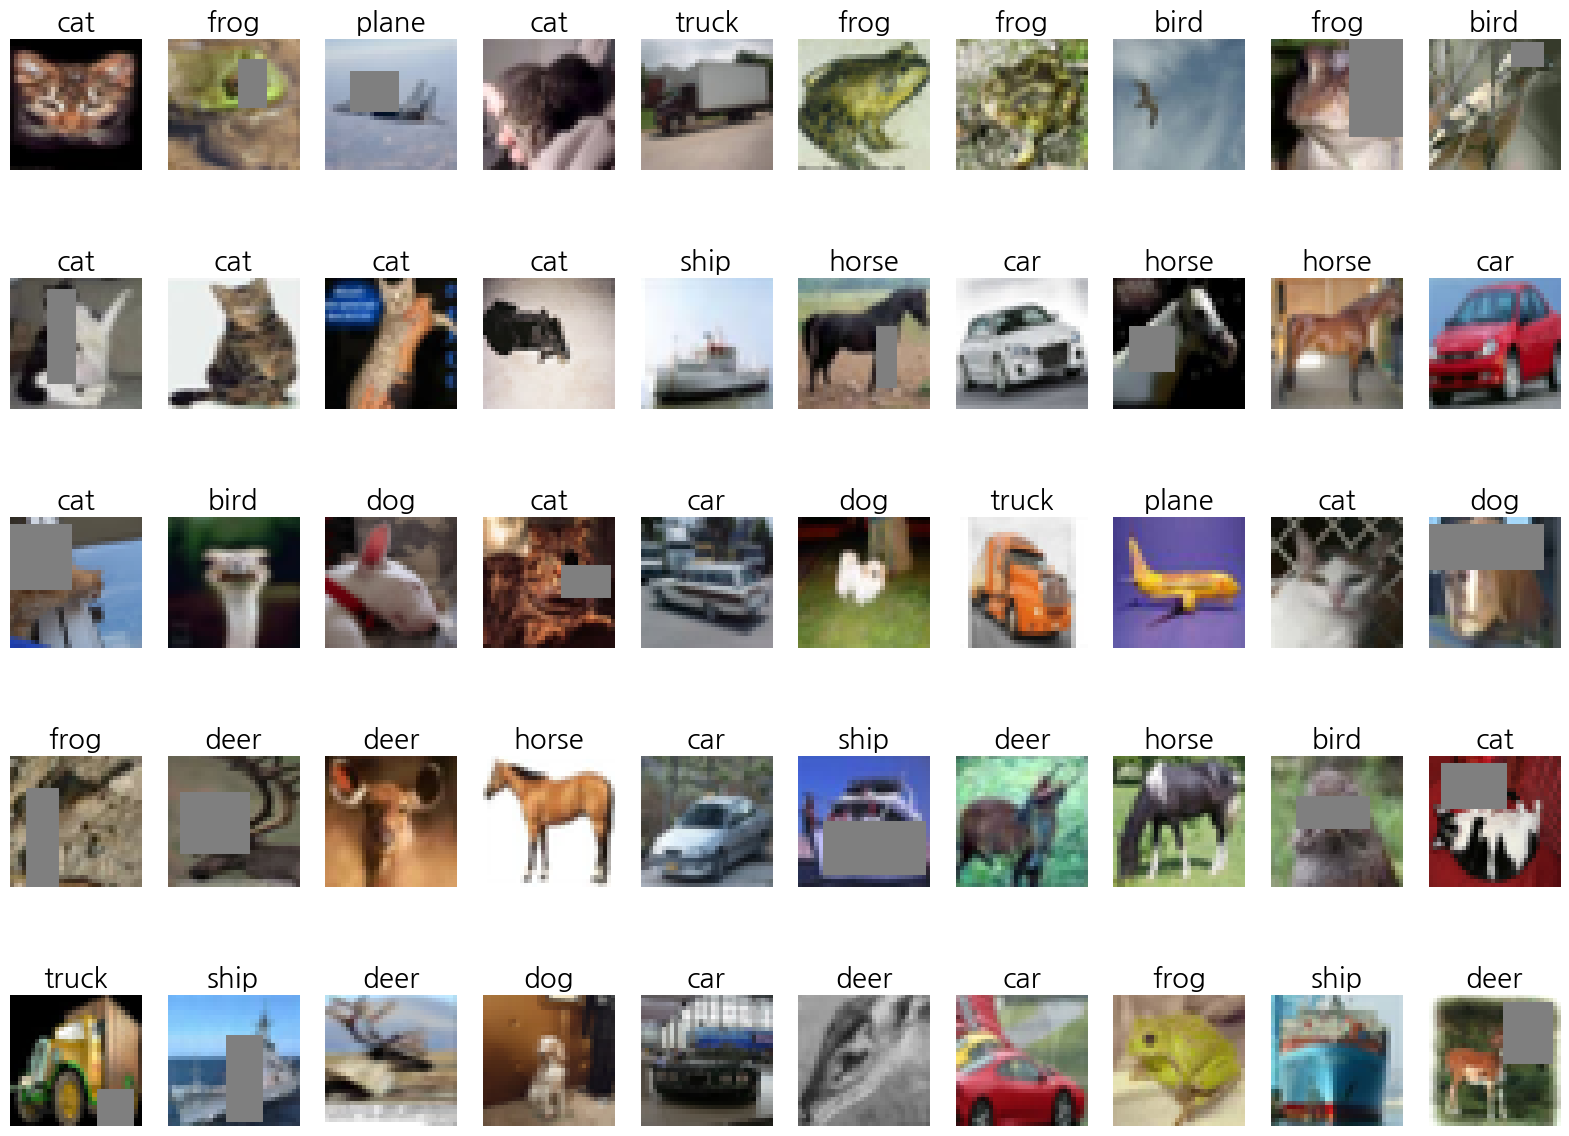

In [ ]:
# 새로운 훈련 데이터의 처음 50개 표시

# 난수 고정
torch_seed()

show_images_labels(train_loader2, classes, None, None)

In [ ]:
# 난수 고정
torch_seed()

# 모델 인스턴스 생성
net = CNN_v4(n_output).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())
history = np.zeros((0, 5))

In [ ]:
# 학습
# 동일한 모델에서 train_loader2로 데이터를 변경

num_epochs = 100
history = fit(net, optimizer, criterion, num_epochs,
        train_loader2, test_loader, device, history)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/100], loss: 0.01539 acc: 0.43650 val_loss: 0.01258, val_acc: 0.54890


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/100], loss: 0.01171 acc: 0.57948 val_loss: 0.00902, val_acc: 0.67320


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [98/100], loss: 0.00355 acc: 0.87738 val_loss: 0.00336, val_acc: 0.89400


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [99/100], loss: 0.00344 acc: 0.88154 val_loss: 0.00327, val_acc: 0.89460


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [100/100], loss: 0.00343 acc: 0.87992 val_loss: 0.00331, val_acc: 0.89500


초기상태 : 손실 : 0.01258  정확도 : 0.54890
최종상태 : 손실 : 0.00331 정확도 : 0.89500


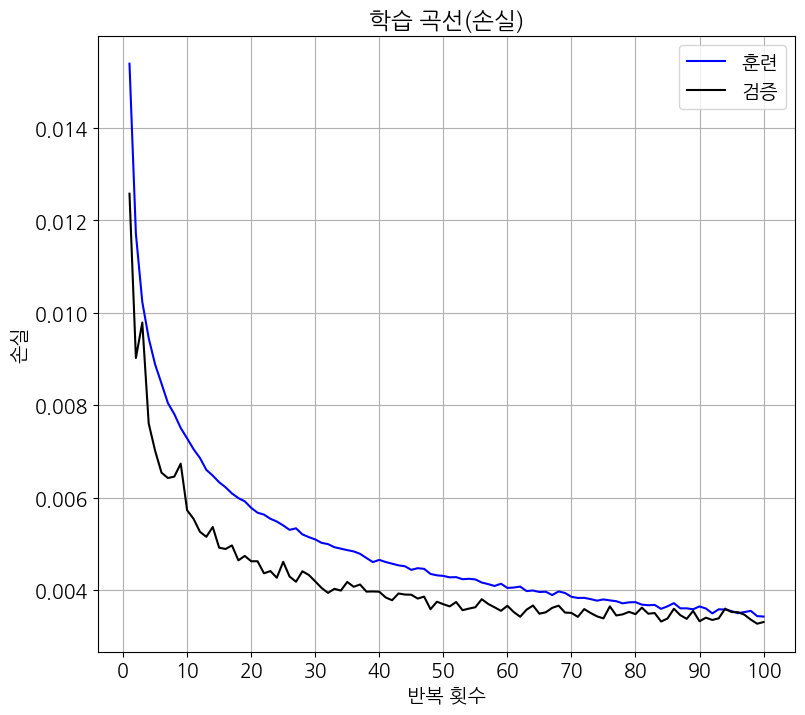

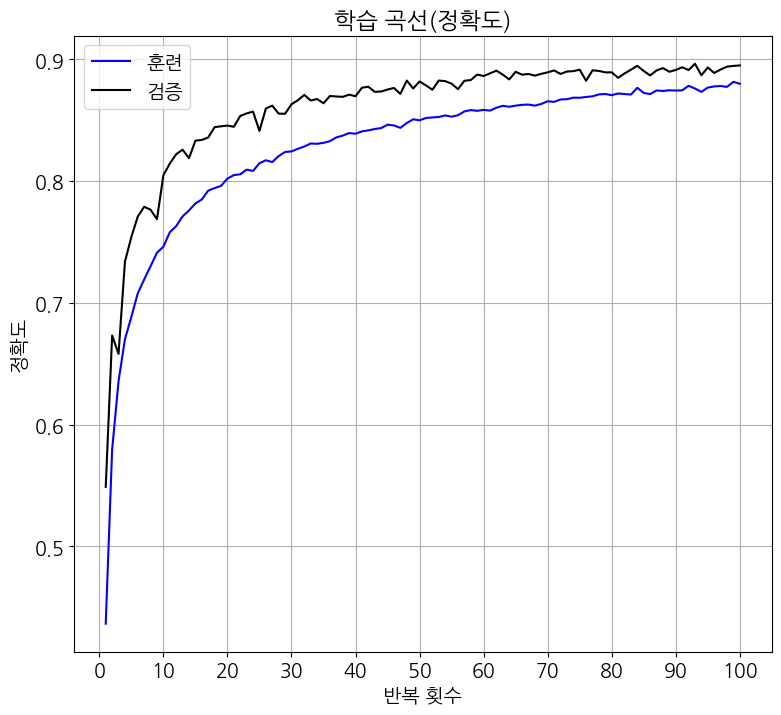

In [ ]:
evaluate_history(history)

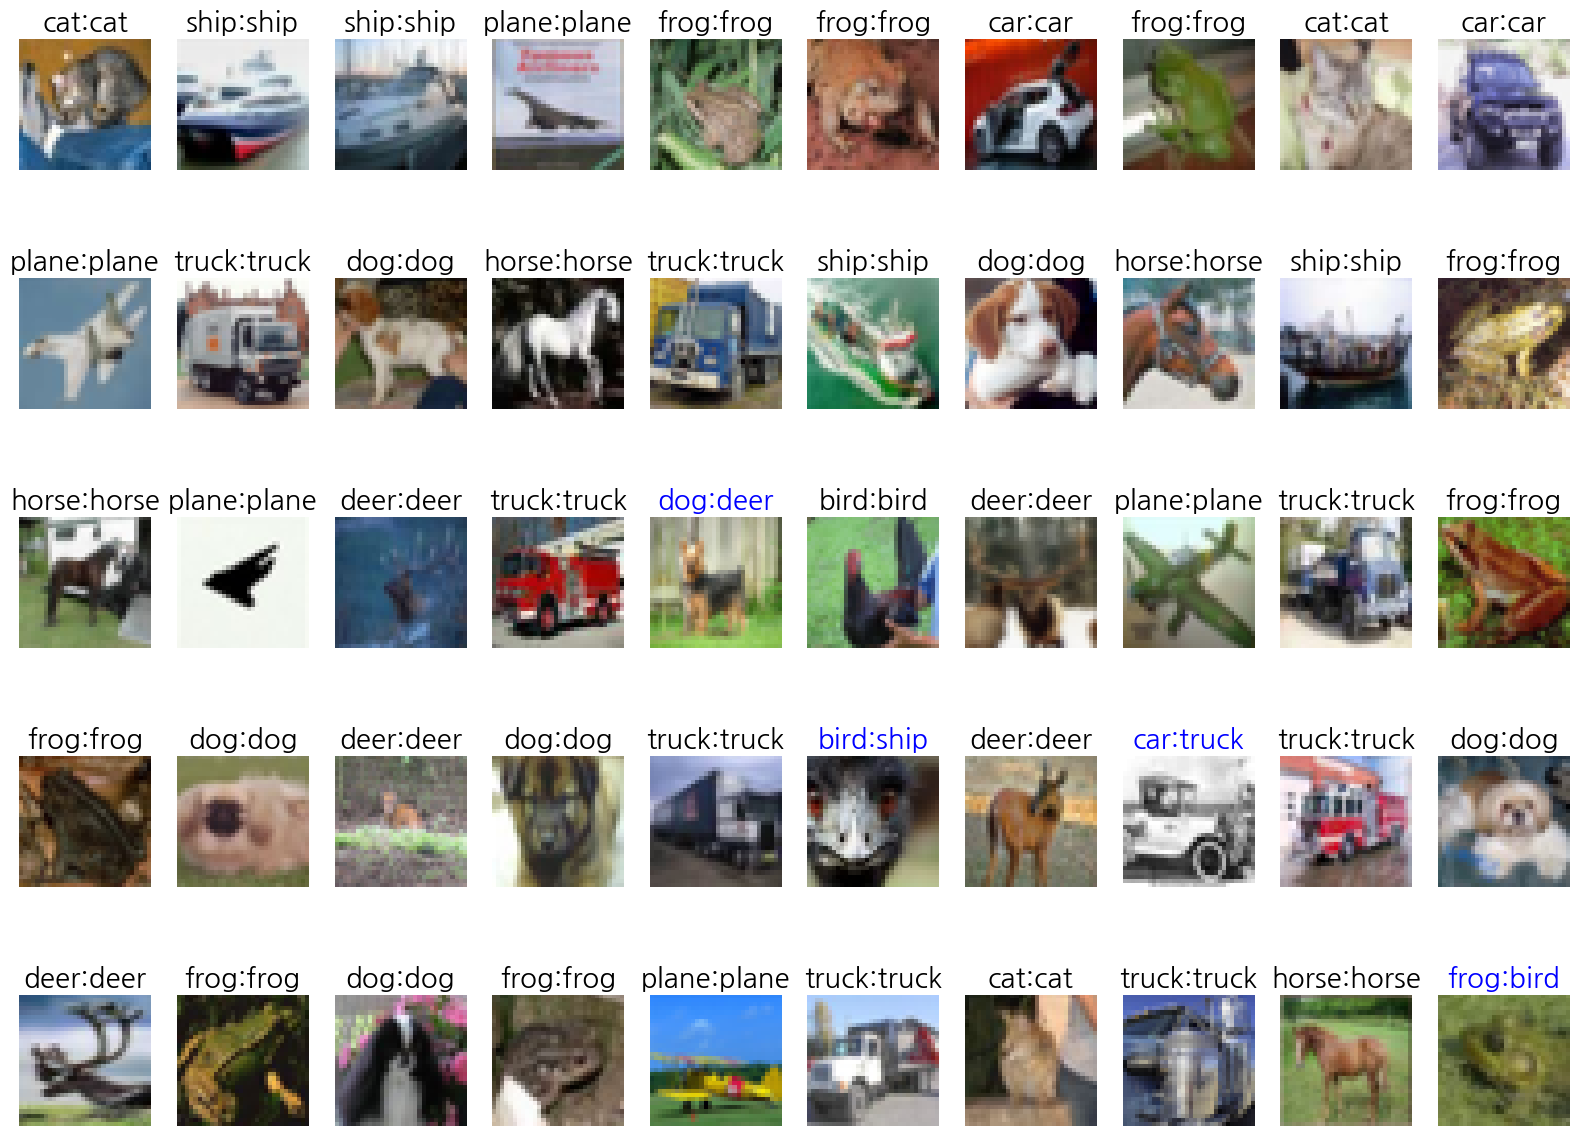

In [ ]:
show_images_labels(test_loader, classes, net, device)

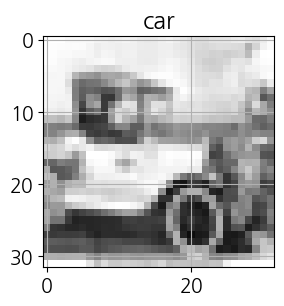

In [ ]:
# 잘못 예측한 38번째 데이터 추출
for images, labels in test_loader:
    break
image = images[37]
label = labels[37]

# 이미지 확인
plt.figure(figsize=(3,3))
w = image.numpy().copy()
# print(w)
print()
w2 = np.transpose(w, (1, 2, 0))
# print(w2)
print()
w3 = (w2 + 1)/2   # 역정규화
# print(w3)
print()
plt.title(classes[label])
plt.imshow(w3)
plt.show()

In [ ]:
# 예측 값 출력
# 원래 이미지 [3,32,32] [CHW]
image = image.view(1, 3, 32, 32) # 1 : 배치차원 추가
image = image.to(device)
output = net(image)

# 라벨 별 확률 값 출력
probs = torch.softmax(output, dim=1)
# dim=1 클래스 방향으로 softmax 적용 >> 확률값으로 나옴 probs

# logits(모델이 예측한 값) >> 확률로 변환(각 클래스에 속할 확률)
probs_np = probs.data.to('cpu').numpy()[0]
# [0] : 배치차원 제거
values = np.frompyfunc(lambda x: f'{x:.04f}', 1, 1)(probs_np)
# frompyfunc(함수, 입력개수, 출력개수)
names = np.array(classes)
tbl = np.array([names, values]).T
print(tbl)

[['plane' '0.1011']
 ['car' '0.1039']
 ['bird' '0.0942']
 ['cat' '0.0974']
 ['deer' '0.0983']
 ['dog' '0.0987']
 ['frog' '0.1101']
 ['horse' '0.1023']
 ['ship' '0.0964']
 ['truck' '0.0976']]


## 칼럼 배치 정규화를 사용할 때 주의할 점

### 잘못된 모델 클래스 정의의 예시

In [ ]:
# # 잘못 정의된 모델 클래스
# class CNN_v5_wrong(nn.Module):
#     def __init__(self, num_classes=10):
#         super().__init__()
#         # ... (conv 레이어들은 이전과 같이 정의) ...
#         self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
#         self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
#         self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
#         self.conv4 = nn.Conv2d(64, 64, 3, padding=1)
#         self.conv5 = nn.Conv2d(64, 128, 3, padding=1)
#         self.conv6 = nn.Conv2d(128, 128, 3, padding=1)
#         self.relu = nn.ReLU(inplace=True)
#         self.maxpool = nn.MaxPool2d(2, 2)
#         self.dropout1 = nn.Dropout(0.2)
#         self.dropout2 = nn.Dropout(0.3)
#         self.dropout3 = nn.Dropout(0.4)

#         self.l1 = nn.Linear(4*4*128, 128)
#         self.l2 = nn.Linear(128, 10)

#         # BN 인스턴스를 3개만 생성
#         self.bn1 = nn.BatchNorm2d(32)
#         self.bn2 = nn.BatchNorm2d(64)
#         self.bn3 = nn.BatchNorm2d(128)

#         self.features = nn.Sequential(
#             self.conv1, self.bn1, self.relu,
#             self.conv2, self.bn1, self.relu, # 여기서 self.bn1을 재사용
#             self.maxpool, self.dropout1,
#             self.conv3, self.bn2, self.relu,
#             self.conv4, self.bn2, self.relu, # 여기서 self.bn2을 재사용
#             self.maxpool, self.dropout2,
#             self.conv5, self.bn3, self.relu,
#             self.conv6, self.bn3, self.relu, # 여기서 self.bn3을 재사용
#             self.maxpool, self.dropout3,
#         )

#         self.classifier = nn.Sequential(
#             self.l1,
#             self.relu,
#             self.dropout3,
#             self.l2
#         )

#     def forward(self, x):
#         x1 = self.features(x)
#         x2 = self.flatten(x1)
#         x3 = self.classifier(x2)
#         return x3

In [ ]:
# 잘못 정의된 모델 클래스
class CNN_v5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # ... (conv 레이어들은 이전과 같이 정의) ...
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv5 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv6 = nn.Conv2d(128, 128, 3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.3)
        self.dropout3 = nn.Dropout(0.4)
        self.flatten = nn.Flatten()

        self.l1 = nn.Linear(4*4*128, 128)
        self.l2 = nn.Linear(128, 10)

        # BN 인스턴스를 3개만 생성
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

        self.features = nn.Sequential(
            self.conv1, self.bn1, self.relu,
            self.conv2, self.bn1, self.relu, # 여기서 self.bn1을 재사용
            self.maxpool, self.dropout1,
            self.conv3, self.bn2, self.relu,
            self.conv4, self.bn2, self.relu, # 여기서 self.bn2을 재사용
            self.maxpool, self.dropout2,
            self.conv5, self.bn3, self.relu,
            self.conv6, self.bn3, self.relu, # 여기서 self.bn3을 재사용
            self.maxpool, self.dropout3,
        )

        self.classifier = nn.Sequential(
            self.l1,
            self.relu,
            self.dropout3,
            self.l2
        )

    def forward(self, x):
        x1 = self.features(x)
        x2 = self.flatten(x1)
        x3 = self.classifier(x2)
        return x3

In [ ]:
# 난수 고정
torch_seed()

# 모델 인스턴스 생성
net = CNN_v5(n_output).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters())
history = np.zeros((0, 5))

In [ ]:
# 학습

num_epochs = 50
history = fit(net, optimizer, criterion, num_epochs, train_loader, test_loader, device, history)

  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [1/50], loss: 0.01497 acc: 0.44862 val_loss: 0.01865, val_acc: 0.33730


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [2/50], loss: 0.01121 acc: 0.59784 val_loss: 0.01920, val_acc: 0.24140


  0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch [48/50], loss: 0.00270 acc: 0.90724 val_loss: 0.03328, val_acc: 0.10300


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [49/50], loss: 0.00264 acc: 0.90850 val_loss: 0.03149, val_acc: 0.12130


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch [50/50], loss: 0.00261 acc: 0.91082 val_loss: 0.03129, val_acc: 0.13720


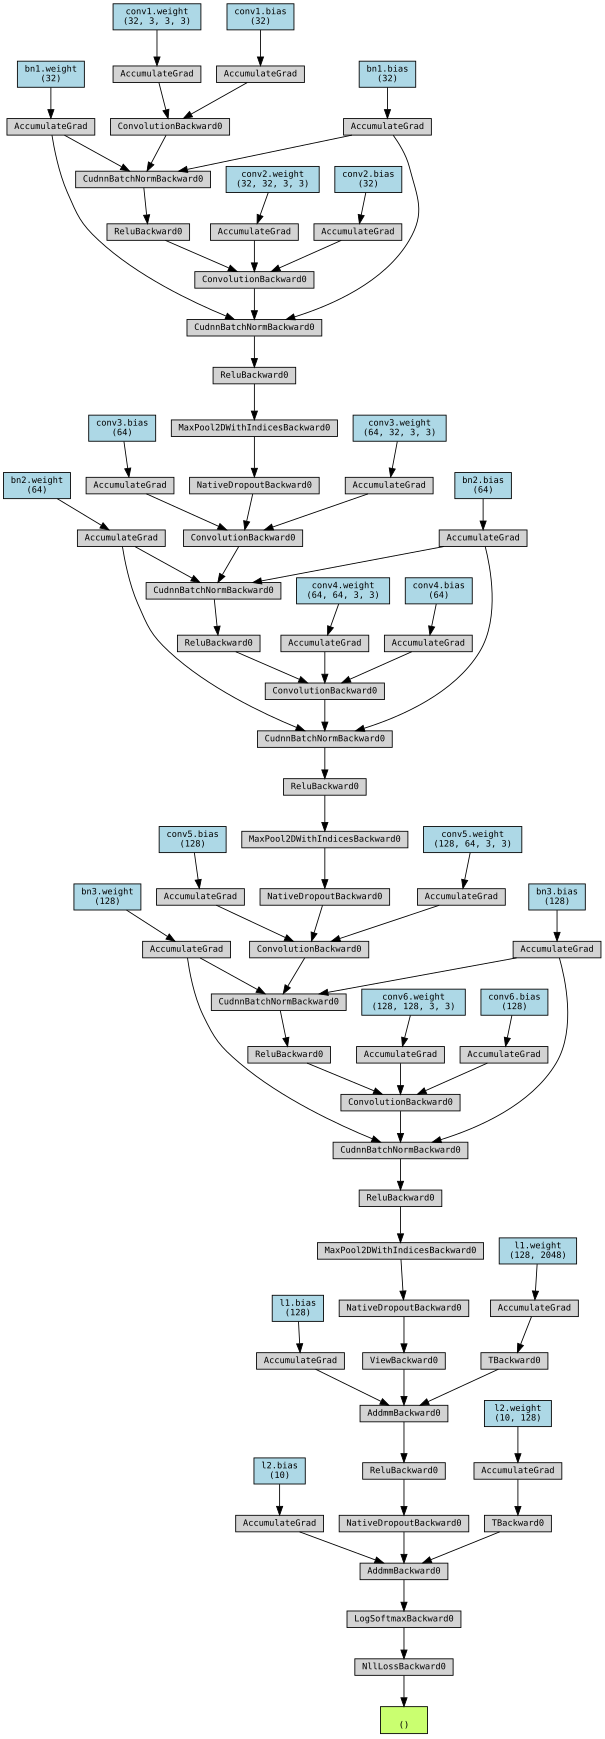

In [ ]:
# 손실 계산 그래프 시각화
net = CNN_v5(n_output).to(device)
criterion = nn.CrossEntropyLoss()
loss = eval_loss(test_loader, device, net, criterion)
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

### 칼럼 배치 정규화에서 처리하는 내용
### 배치 정규화 동작 원리 코드

In [ ]:
# 입력용 더미 데이터 작성
torch.manual_seed(123)
inputs = torch.randn(1, 1, 10)
print(inputs)

tensor([[[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969,  0.2093, -0.9724,
          -0.7550,  0.3239, -0.1085]]])


In [ ]:
# 입력 미니 배치 데이터의 통계량 산출
i_mean = inputs.mean()
i_var = inputs.var(unbiased=True) # running_var 업데이트에 사용
i_std = inputs.std(unbiased=False) # 훈련 출력 계산에 사용
print(f"입력 평균: {i_mean:.4f}, 입력 표준편차: {i_std:.4f}, 입력 분산: {i_var:.4f}\n")
# unbiased variance 불편(편향 bias 이 없음) 분산 (표본 분산 사용)
# unbiased=True >> 분모가 n-1 (표본분산)
# unbiased=False >> 분모가 n (모집단 표준편차)

# 표본분산의 분모가 n-1인 이유
# 평균이 정해지게 되면, 마지막 값은 degree of freedom(자유도)를 읽게 된다.
# 데이터 개수가 n개일 때, 실제로 독립적으로 움직일 수 있는 값이 n-1이 된다.
# sample에서 뽑는 값이라 n-1을 해야 한다. 전체 실제 평균과 차이가 있게 된다.
# 분모를 작게 해야 분산이 작게 나와서 모집단과 좀 더 유사하게 된다.
# -> 자유도로 나눠주는 것이 표준 = unbiased estimator

입력 평균: -0.3101, 입력 표준편차: 0.4867, 입력 분산: 0.2632



In [ ]:
# BN 함수 정의 및 초기 상태 출력
bn = nn.BatchNorm1d(1) # 1차원 배치 정규화 (채널수 1)
print(f"초기 running_mean: {bn.running_mean.data}")
print(f"초기 running_var: {bn.running_var.data}")
print(f"초기 weight: {bn.weight.data}")
print(f"초기 bias: {bn.bias.data}")

초기 running_mean: tensor([0.])
초기 running_var: tensor([1.])
초기 weight: tensor([1.])
초기 bias: tensor([0.])


In [ ]:
# BN 함수의 유사 호출
bn.train()
outputs1_train = bn(inputs)
print(f"--- 훈련 페이즈 1 ---")
print(f"출력: {outputs1_train.data.numpy().round(4)}")
print(f"이후 running_mean: {bn.running_mean.data.numpy().round(4)}")
print(f"이후 running_var: {bn.running_var.data.numpy().round(4)}\n")

bn.eval()
outputs1_eval = bn(inputs)
print(f"--- 예측 페이지 1 ---")
print(f"출력: {outputs1_eval.data.numpy().round(4)}")
print(f"이후 running_mean: {bn.running_mean.data.numpy().round(4)}")
print(f"이후 running_var: {bn.running_var.data.numpy().round(4)}\n")

bn.train()
outputs2_train = bn(inputs)
print(f"--- 훈련 페이즈 2 ---")
print(f"출력: {outputs2_train.data.numpy().round(4)}")
print(f"이후 running_mean: {bn.running_mean.data.numpy().round(4)}")
print(f"이후 running_var: {bn.running_var.data.numpy().round(4)}\n")

bn.eval()
outputs2_eval = bn(inputs)
print(f"--- 예측 페이지 2 ---")
print(f"출력: {outputs2_eval.data.numpy().round(4)}")
print(f"이후 running_mean: {bn.running_mean.data.numpy().round(4)}")
print(f"이후 running_var: {bn.running_var.data.numpy().round(4)}\n")

--- 훈련 페이즈 1 ---
출력: [[[ 0.4081  0.8844 -0.1224  0.1431 -1.8222  1.0671 -1.3608 -0.9143
    1.3027  0.4142]]]
이후 running_mean: [-0.031]
이후 running_var: [0.9263]

--- 예측 페이지 1 ---
출력: [[[-0.0836  0.1573 -0.3518 -0.2176 -1.2114  0.2496 -0.9781 -0.7523
    0.3688 -0.0805]]]
이후 running_mean: [-0.031]
이후 running_var: [0.9263]

--- 훈련 페이즈 2 ---
출력: [[[ 0.4081  0.8844 -0.1224  0.1431 -1.8222  1.0671 -1.3608 -0.9143
    1.3027  0.4142]]]
이후 running_mean: [-0.0589]
이후 running_var: [0.86]

--- 예측 페이지 2 ---
출력: [[[-0.0567  0.1933 -0.3351 -0.1957 -1.2271  0.2892 -0.985  -0.7507
    0.4128 -0.0535]]]
이후 running_mean: [-0.0589]
이후 running_var: [0.86]



In [ ]:
# 훈련 페이즈 계산 검증
xt = (inputs - i_mean)/i_std * bn.weight + bn.bias
# 표준정규분포(표준화) 평균 0, 표준편차 1
# 공식: x - x_bar(mean) / sigma(표준편차)
# 이 표준화 공식에 gamma( bn.weight) 스케일링 해주고, beta (배치정규화한 편향) 더함

print("수동 훈련 출력과 파이토치 결과 일치:", torch.allclose(xt.data, outputs2_train.data))
print(xt.data)
print(outputs2_train.data)

# torch.allclose : 제시된 두 개의 텐서가 같거나 유사한지 확인(부동소수점 오차까지만 허용)

수동 훈련 출력과 파이토치 결과 일치: False
tensor([[[ 0.4081,  0.8845, -0.1224,  0.1431, -1.8223,  1.0671, -1.3608,
          -0.9143,  1.3027,  0.4142]]])
tensor([[[ 0.4081,  0.8844, -0.1224,  0.1431, -1.8222,  1.0671, -1.3608,
          -0.9143,  1.3027,  0.4142]]])


In [ ]:
# 예측 페이즈 계산 검증
xp = (inputs-bn.running_mean)/torch.sqrt(bn.running_var)

print("수동 예측 출력과 파이토치 결과 일치:", torch.allclose(xp.data, outputs2_eval.data))
print(xp.data)
print(outputs2_eval.data)

수동 예측 출력과 파이토치 결과 일치: True
tensor([[[-0.0567,  0.1933, -0.3351, -0.1957, -1.2271,  0.2892, -0.9850,
          -0.7507,  0.4128, -0.0535]]])
tensor([[[-0.0567,  0.1933, -0.3351, -0.1957, -1.2271,  0.2892, -0.9850,
          -0.7507,  0.4128, -0.0535]]])


In [ ]:
# running_mean과 runnung_var의 계산식

# 초깃값
mean0 = 0
var0 = 1
momentum = bn.momentum

# 이동 평균 계산 1회차 -> bn.running_mean 은 2회차까지 갱신된 값이라 비교 시 False
# 지수이동평균
mean1 = (1-momentum) * mean0 +  momentum * i_mean
var1 = (1-momentum) * var0 +  momentum * i_var
print("수동 running_mean과 파이토치 결과 일치:", torch.allclose(mean1, bn.running_mean))
print(mean1, var1)

# 이동 평균 계산 2회차 -> 2회차 기준 값이기 때문에 비교 시 True
mean2 = (1-momentum) * mean1 +  momentum * i_mean
var2 = (1-momentum) * var1 +  momentum * i_var
print("수동 running_var과 파이토치 결과 일치:", torch.allclose(var2, bn.running_var))
print(mean2, var2)

수동 running_mean과 파이토치 결과 일치: False
tensor(-0.0310) tensor(0.9263)
수동 running_var과 파이토치 결과 일치: True
tensor(-0.0589) tensor(0.8600)
